# Equity Framing Exploratory Data Analysis (EDA)

## Overview
This notebook performs an exploratory data analysis of sentence-level equity framing across all document categories.
Each observation is a sentence with document-level identifiers, allowing both sentence-level and document-aware summaries.

The objective is to understand how equity language patterns vary across and between all source types (academic, federal policy, NGO/nonprofit, news/commentary, state/local) before moving to formal modeling. **No single category is used as a baseline; all categories are compared symmetrically.**

## Objectives
- Inspect dataset structure, feature types, and core quality indicators
- Compare equity vs non-equity sentence balance across the corpus
- Analyze cross-category differences in equity sentence volume and normalized rates through statistical tests
- Conduct pairwise comparisons between all category pairs to identify significant differences
- Examine category co-occurrence patterns and document-level composition
- Review definition vs operational equity framing across categories
- Flag analytic risks (for example, sparse categories or document-level clustering effects)
- Generate practical insights to guide downstream inferential and predictive analysis

## Dataset Description
The analytic dataset combines sentence-level text records with category and subtype metadata from multiple document sources.
Core variables include `document_id`, `sentence_id`, `category`, `document_subtype`, sentence text, and equity indicator flags.

Key framing variables include `contains_equity`, `contains_equities`, `contains_health_equity`, and `contains_related_terms`.

## Key Considerations
- Sentence records are nested within documents, so interpretation should account for clustering
- Category and subtype sizes may be uneven, affecting comparability and variance
- Indicator fields may require harmonization due to source-format inconsistencies
- Equity mentions can be sparse in some groups, requiring caution in small-sample conclusions
- Length-based measures (word_count, char_count) can confound interpretation if not contextualized
- All five categories (academic, federal_policy, ngo_nonprofit, news_commentary, state_local) are treated symmetrically in analysis

## Outcome
Insights from this EDA support variable construction, balanced multiway comparison design, and robust model-specification choices for later stages.

In [4]:
# Project workflow commands (run in terminal)
# quarto preview 01_eda.ipynb --to pdf
# quarto render 01_eda.ipynb
# black 01_eda.ipynb

In [5]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Paths
INPUT_CSV = Path("../01_data/full_sentence_corpus.csv")
TABLES_DIR = Path("../01_data/raw_data")
TABLES_DIR.mkdir(parents=True, exist_ok=True)


pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 120

# Consistent color palette for categories
CATEGORY_COLORS = {
    "academic": "#2E86AB",
    "federal_policy": "#A23B72",
    "ngo_nonprofit": "#06A77D",
    "news_commentary": "#F77F00",
    "state_local": "#D62828",
}

# Binary colors (equity vs non-equity)
BINARY_COLORS = ["#2E86AB", "#A23B72"]


def save_table(df_: pd.DataFrame, name: str) -> None:
    df_.to_csv(TABLES_DIR / name, index=False, encoding="utf-8-sig")


def save_plot(name: str) -> None:
    plt.tight_layout()
    plt.show()
    plt.close()


def to_bool(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s.fillna(False)
    true_vals = {"true", "t", "1", "yes", "y"}
    x = s.astype(str).str.strip().str.lower()
    return x.isin(true_vals)


print("Setup complete. Tables and plots will be saved to ../01_data/raw_data/")

Setup complete. Tables and plots will be saved to ../01_data/raw_data/


## 1) Load Data and Keep Needed Columns
This keeps the script concise and focused on variables needed for cross-document-type equity framing analysis.

In [6]:
candidates = [
    INPUT_CSV,
    Path("full_sentence_corpus.csv"),
    Path("equity_sentence_subset.csv"),
]
input_path = next((p for p in candidates if p.exists()), None)
if input_path is None:
    raise FileNotFoundError("Could not find an input CSV.")

df = pd.read_csv(input_path, low_memory=False)

required = [
    "document_id",
    "sentence_id",
    "category",
    "document_subtype",
    "sentence_text",
    "contains_equity",
    "contains_equities",
    "contains_health_equity",
    "contains_related_terms",
    "is_definition_sentence",
    "word_count",
    "char_count",
]
for c in required:
    if c not in df.columns:
        df[c] = pd.NA if c in {"word_count", "char_count"} else ""

for c in [
    "contains_equity",
    "contains_equities",
    "contains_health_equity",
    "contains_related_terms",
    "is_definition_sentence",
]:
    df[c] = to_bool(df[c])

if df["document_id"].astype(str).str.strip().eq("").all():
    df["document_id"] = "doc_" + (df.index + 1).astype(str)

if df["word_count"].isna().all():
    df["word_count"] = df["sentence_text"].fillna("").str.split().str.len()
if df["char_count"].isna().all():
    df["char_count"] = df["sentence_text"].fillna("").str.len()

keep_cols = [
    "document_id",
    "sentence_id",
    "category",
    "document_subtype",
    "sentence_text",
    "contains_equity",
    "contains_equities",
    "contains_health_equity",
    "contains_related_terms",
    "is_definition_sentence",
    "word_count",
    "char_count",
]
df = df[keep_cols].copy()

# Create equity subset (primary equity indicator)
df_equity = df[df["contains_equity"]].copy()

print(f"Loaded {len(df):,} sentences from: {input_path.resolve()}")
print(
    f"Equity subset: {len(df_equity):,} sentences ({len(df_equity)/len(df)*100:.1f}%)"
)

Loaded 27,365 sentences from: /Users/far/Downloads/TEXTasDATA/IDS570_Text_as_Data_final_Project/01_data/full_sentence_corpus.csv
Equity subset: 4,060 sentences (14.8%)


## 2) Equity Subset and Core Balance Snapshot
This establishes the analytic subset and checks if category/document coverage is adequate for downstream modeling.

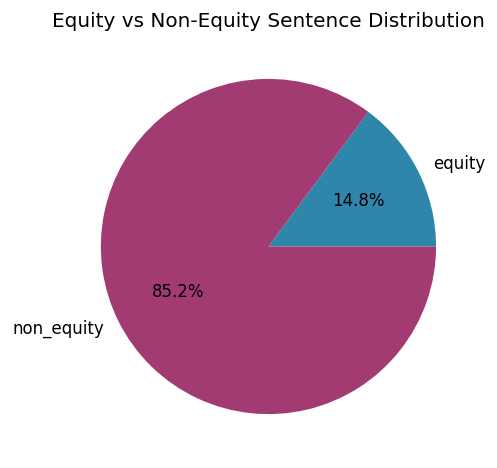

Insight: This checks whether the target concept is sparse and whether class imbalance handling may be needed.


In [7]:
# Why this plot: immediate class-balance view for equity vs non-equity sentence classification tasks.
eq_balance = pd.DataFrame(
    {
        "group": ["equity", "non_equity"],
        "sentences": [len(df_equity), len(df) - len(df_equity)],
    }
)
plt.figure(figsize=(6, 4))
plt.pie(
    eq_balance["sentences"],
    labels=eq_balance["group"],
    autopct="%1.1f%%",
    colors=BINARY_COLORS,
)
plt.title("Equity vs Non-Equity Sentence Distribution")
save_plot("01_equity_balance_pie.png")

print(
    "Insight: This checks whether the target concept is sparse and whether class imbalance handling may be needed."
)

### Interpretation — Equity vs Non-Equity Balance

**RQ relevance:** Before comparing categories, this plot establishes the overall scarcity of equity-related language in the corpus. If equity sentences represent a small fraction of the total, any cross-category comparison must account for this baseline sparsity — small absolute differences between categories may still represent meaningful proportional variation. A highly imbalanced corpus also signals that downstream models will need class-weighting or resampling strategies regardless of which category is under focus.


## 3) Cross-Document-Type Equity Usage Comparison
These plots directly compare equity volume and equity rate across document types.

          category  total_sentences  equity_sentences  documents  equity_rate_per_100
4      state_local            12337              2202         21                17.85
1   federal_policy             8533              1036         18                12.14
3    ngo_nonprofit             5581               630         17                11.29
2  news_commentary              483                52         23                10.77
0         academic              431               140         49                32.48


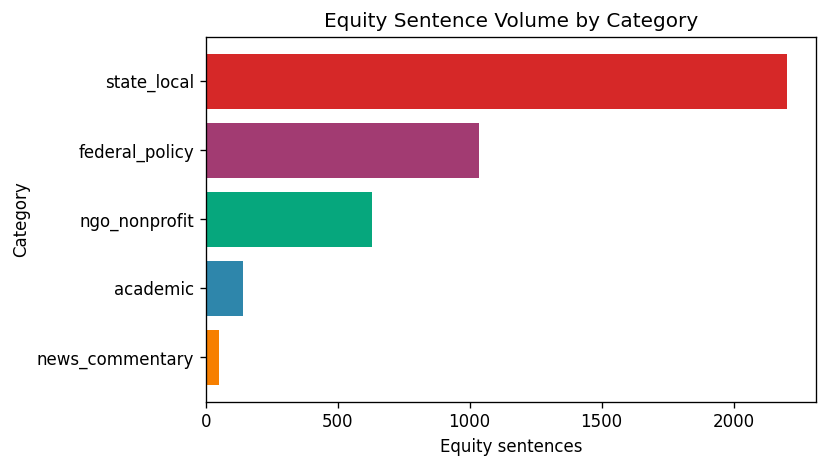

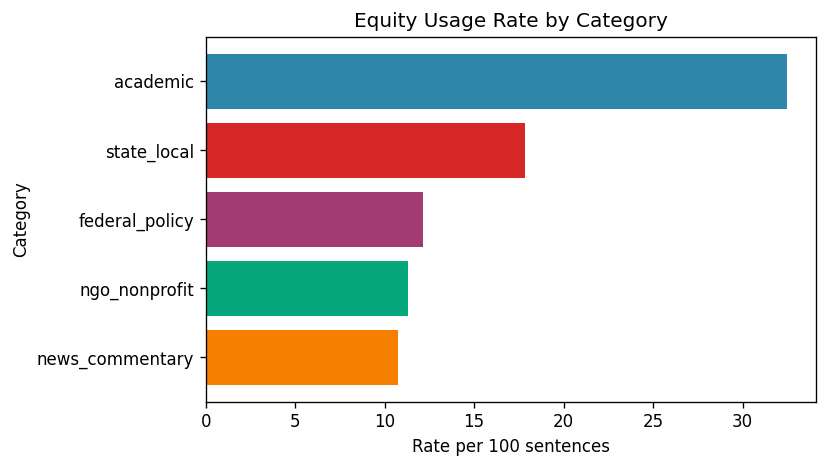

Insight: Together these distinguish high-volume categories from high-intensity equity framing categories.


In [8]:
cat_total = df.groupby("category", dropna=False).size().rename("total_sentences")
cat_equity = (
    df_equity.groupby("category", dropna=False).size().rename("equity_sentences")
)
cat_docs = (
    df.groupby("category", dropna=False)["document_id"].nunique().rename("documents")
)

cat = pd.concat([cat_total, cat_equity, cat_docs], axis=1).fillna(0).reset_index()
cat[["total_sentences", "equity_sentences", "documents"]] = cat[
    ["total_sentences", "equity_sentences", "documents"]
].astype(int)
cat["equity_rate_per_100"] = (
    (cat["equity_sentences"] / cat["total_sentences"].replace(0, pd.NA) * 100)
    .fillna(0)
    .round(2)
)
cat = cat.sort_values("total_sentences", ascending=False)
save_table(cat, "02_category_equity_comparison.csv")
print(cat)

# Why this plot: compares absolute equity discourse volume by document type.
plt.figure(figsize=(7, 4))
cat_sorted = cat.sort_values("equity_sentences", ascending=True)
colors = [CATEGORY_COLORS[cat] for cat in cat_sorted["category"]]
plt.barh(
    cat_sorted["category"].astype(str), cat_sorted["equity_sentences"], color=colors
)
plt.xlabel("Equity sentences")
plt.ylabel("Category")
plt.title("Equity Sentence Volume by Category")
save_plot("02_equity_volume_by_category.png")

# Why this plot: compares normalized usage intensity, not biased by corpus size differences.
plt.figure(figsize=(7, 4))
cat_sorted_rate = cat.sort_values("equity_rate_per_100", ascending=True)
colors_rate = [CATEGORY_COLORS[cat] for cat in cat_sorted_rate["category"]]
plt.barh(
    cat_sorted_rate["category"].astype(str),
    cat_sorted_rate["equity_rate_per_100"],
    color=colors_rate,
)
plt.xlabel("Rate per 100 sentences")
plt.ylabel("Category")
plt.title("Equity Usage Rate by Category")
save_plot("03_equity_rate_by_category.png")

print(
    "Insight: Together these distinguish high-volume categories from high-intensity equity framing categories."
)

### Interpretation — Equity Volume and Rate by Category

**RQ relevance:** These two plots are central to the multiway comparison. The **volume plot** answers: *Which categories produce the most equity-related sentences in absolute terms?* The **rate plot** answers: *Which categories are most intensely focused on equity relative to their total output?* A category can rank high on volume but low on rate (large corpus, modest focus) or vice versa (small corpus, dense equity framing). Comparing all five categories simultaneously — with no category treated as a reference — reveals which source types are the strongest and weakest equity discourse producers. If certain categories cluster together in both volume and rate, that signals meaningful structural similarity in how those communities discuss equity.


## 4) Definition vs Usage Framing by Document Type
This tests whether document types differ in explicit definition-style equity language.

          category  equity_sentences  definition_sentences  definition_rate_pct
0         academic               140                    13                 9.29
1   federal_policy              1036                    39                 3.76
2  news_commentary                52                     1                 1.92
3    ngo_nonprofit               630                    14                 2.22
4      state_local              2202                    85                 3.86


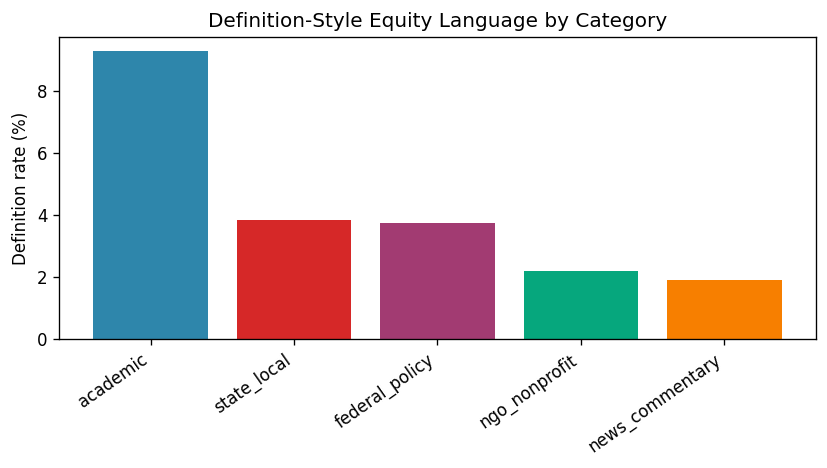

Insight: Higher definition rates indicate categories where equity is discussed more conceptually than operationally.


In [9]:
def_cat = (
    df_equity.groupby("category", dropna=False)
    .agg(
        equity_sentences=("sentence_text", "size"),
        definition_sentences=("is_definition_sentence", "sum"),
    )
    .reset_index()
)
def_cat["definition_sentences"] = def_cat["definition_sentences"].astype(int)
def_cat["definition_rate_pct"] = (
    (
        def_cat["definition_sentences"]
        / def_cat["equity_sentences"].replace(0, pd.NA)
        * 100
    )
    .fillna(0)
    .round(2)
)
save_table(def_cat, "03_definition_vs_usage_by_category.csv")
print(def_cat)

# Why this plot: directly compares conceptual/definitional framing intensity across document types.
plt.figure(figsize=(7, 4))
def_cat_sorted = def_cat.sort_values("definition_rate_pct", ascending=False)
colors_def = [CATEGORY_COLORS[cat] for cat in def_cat_sorted["category"]]
plt.bar(
    range(len(def_cat_sorted)), def_cat_sorted["definition_rate_pct"], color=colors_def
)
plt.xticks(
    range(len(def_cat_sorted)), def_cat_sorted["category"], rotation=35, ha="right"
)
plt.ylabel("Definition rate (%)")
plt.title("Definition-Style Equity Language by Category")
save_plot("04_definition_rate_by_category.png")

# Why this table: clearer than another plot for reporting exact counts and rates.
print(
    "Insight: Higher definition rates indicate categories where equity is discussed more conceptually than operationally."
)

### Interpretation — Definition-Style Equity Language by Category

**RQ relevance:** Beyond how *much* equity language appears in each category, this plot reveals *how* it is used. A high definition rate means a category tends to explain or define equity conceptually (e.g., "health equity is defined as…"), while a low rate suggests equity is invoked instrumentally or operationally without explicit definition. Comparing definition rates across all five categories simultaneously can distinguish categories that frame equity as a concept to be understood from those that treat it as action-oriented shorthand. For example, if `academic` and `ngo_nonprofit` show high definition rates while `news_commentary` and `state_local` show low rates, this suggests fundamentally different rhetorical purposes — a finding directly relevant to understanding cross-sector equity discourse.


## 5) Document-Level Structure (Sentences Nested in Documents)
These analyses ensure document dependency is visible before any sentence-level modeling.

             metric  count        mean         std  min  25%     50%     75%     max
0   total_sentences  128.0  213.789062  332.792401  1.0  5.0  12.000  299.25  1597.0
1  equity_sentences  128.0   31.718750   62.576937  0.0  0.0   5.000   27.50   349.0
2  equity_share_pct  128.0   23.263672   26.189731  0.0  0.0  14.595   40.00   100.0


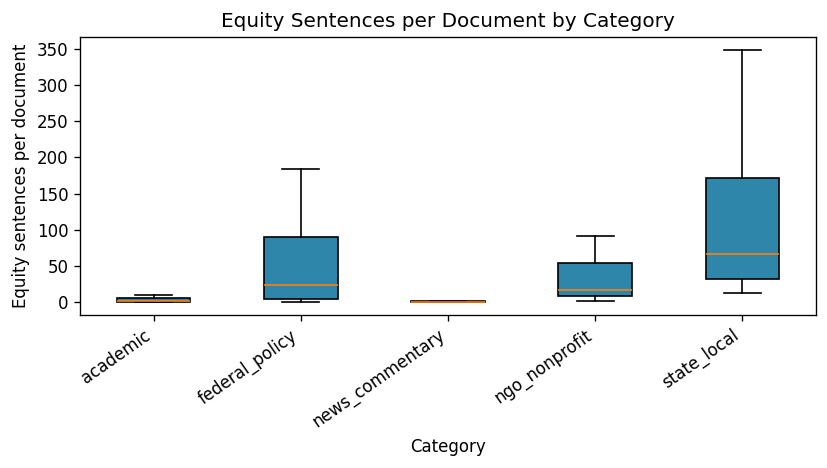

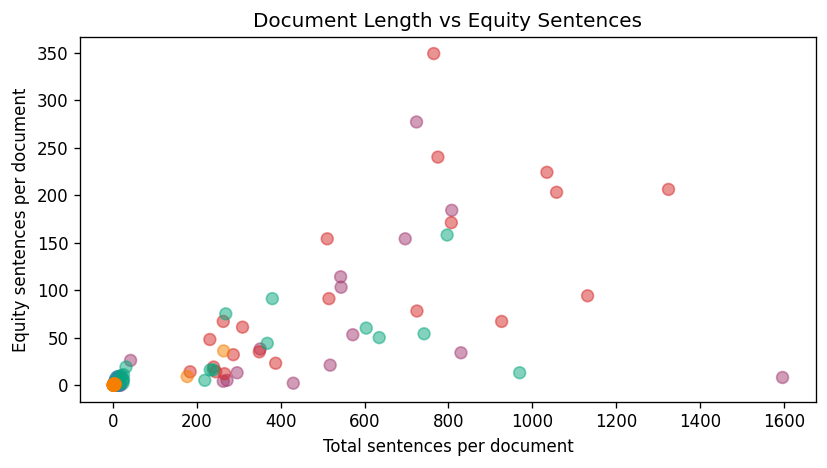

Insight: These plots show nested structure and whether long documents dominate equity-sentence signal.


In [10]:
doc_total = df.groupby("document_id", dropna=False).size().rename("total_sentences")
doc_equity = (
    df_equity.groupby("document_id", dropna=False).size().rename("equity_sentences")
)
doc_cat = df[["document_id", "category"]].drop_duplicates(subset=["document_id"])

doc_stats = doc_cat.merge(doc_total.reset_index(), on="document_id", how="left").merge(
    doc_equity.reset_index(), on="document_id", how="left"
)
doc_stats["equity_sentences"] = doc_stats["equity_sentences"].fillna(0).astype(int)
doc_stats["equity_share_pct"] = (
    (
        doc_stats["equity_sentences"]
        / doc_stats["total_sentences"].replace(0, pd.NA)
        * 100
    )
    .fillna(0)
    .round(2)
)
save_table(doc_stats, "04_document_level_stats.csv")

summary = (
    doc_stats[["total_sentences", "equity_sentences", "equity_share_pct"]]
    .describe()
    .T.reset_index()
    .rename(columns={"index": "metric"})
)
save_table(summary, "05_document_level_summary.csv")
print(summary)

# Why this plot: reveals heterogeneity and clustering of equity content across document types.
groups = [
    g["equity_sentences"].values for _, g in doc_stats.groupby("category", dropna=False)
]
labels = [str(k) for k, _ in doc_stats.groupby("category", dropna=False)]
plt.figure(figsize=(7, 4))
bp = plt.boxplot(groups, tick_labels=labels, showfliers=False, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#2E86AB")
plt.title("Equity Sentences per Document by Category")
plt.xlabel("Category")
plt.ylabel("Equity sentences per document")
plt.xticks(rotation=35, ha="right")
save_plot("05_equity_sentences_per_doc_boxplot.png")

# Why this plot: checks whether equity counts are mostly a function of document length.
plt.figure(figsize=(7, 4))
colors_scatter = [CATEGORY_COLORS[cat] for cat in doc_stats["category"]]
plt.scatter(
    doc_stats["total_sentences"],
    doc_stats["equity_sentences"],
    alpha=0.5,
    s=50,
    c=colors_scatter,
)
plt.xlabel("Total sentences per document")
plt.ylabel("Equity sentences per document")
plt.title("Document Length vs Equity Sentences")
save_plot("06_doc_length_vs_equity_scatter.png")

print(
    "Insight: These plots show nested structure and whether long documents dominate equity-sentence signal."
)

### Interpretation — Document-Level Equity Sentence Distribution

**RQ relevance:** These plots shift the unit of analysis from sentence to document, which is essential for valid cross-category comparison. The **boxplot** reveals within-category heterogeneity: if one category has a wide spread of equity sentences per document, it means that category is internally diverse rather than uniformly equity-focused. The **scatter plot** checks whether some categories appear equity-rich simply because their documents are long. If equity sentence counts scale tightly with document length within a category, the category's apparent intensity is partially an artifact of verbosity. These diagnostics ensure that category differences observed in Section 3 reflect genuine framing choices, not structural differences in document length or corpus composition.


## 5.5) Pairwise Category Comparisons
These tables systematically compare every pair of categories to identify which differ meaningfully in equity framing intensity.


Pairwise Equity Rate Comparisons (sorted by largest difference):
        category_1       category_2  rate_1_pct  rate_2_pct  rate_difference cat1_higher
1         academic  news_commentary       32.48       10.77            21.72         Yes
2         academic    ngo_nonprofit       32.48       11.29            21.19         Yes
0         academic   federal_policy       32.48       12.14            20.34         Yes
3         academic      state_local       32.48       17.85            14.63         Yes
4   federal_policy  news_commentary       12.14       10.77             1.38         Yes
5   federal_policy    ngo_nonprofit       12.14       11.29             0.85         Yes
7  news_commentary    ngo_nonprofit       10.77       11.29            -0.52          No
6   federal_policy      state_local       12.14       17.85            -5.71          No
9    ngo_nonprofit      state_local       11.29       17.85            -6.56          No
8  news_commentary      state_local       10.

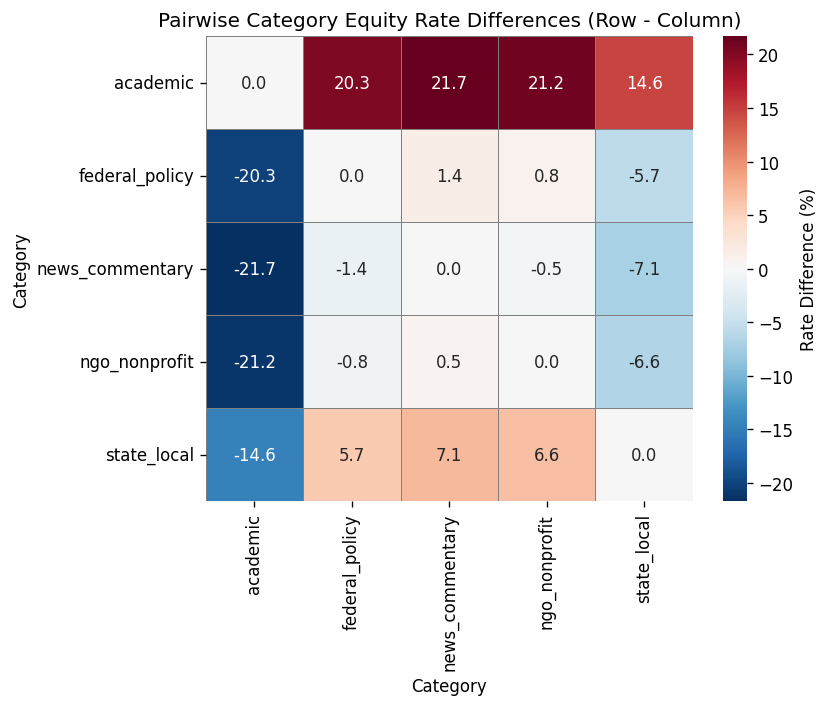

Insight: Positive values indicate Category A has higher equity rate than Category B.


In [11]:
# Generate pairwise comparisons across all categories
categories = sorted(df["category"].unique())
pairwise_comparisons = []

for i, cat1 in enumerate(categories):
    for cat2 in categories[i + 1 :]:
        cat1_equity_rate = (
            (
                df_equity[df_equity["category"] == cat1].shape[0]
                / df[df["category"] == cat1].shape[0]
                * 100
            )
            if df[df["category"] == cat1].shape[0] > 0
            else 0
        )
        cat2_equity_rate = (
            (
                df_equity[df_equity["category"] == cat2].shape[0]
                / df[df["category"] == cat2].shape[0]
                * 100
            )
            if df[df["category"] == cat2].shape[0] > 0
            else 0
        )

        rate_diff = cat1_equity_rate - cat2_equity_rate
        pairwise_comparisons.append(
            {
                "category_1": cat1,
                "category_2": cat2,
                "rate_1_pct": round(cat1_equity_rate, 2),
                "rate_2_pct": round(cat2_equity_rate, 2),
                "rate_difference": round(rate_diff, 2),
                "cat1_higher": "Yes" if rate_diff > 0 else "No",
            }
        )

pairwise_df = pd.DataFrame(pairwise_comparisons).sort_values(
    "rate_difference", ascending=False
)
save_table(pairwise_df, "05_pairwise_category_equity_rates.csv")
print("Pairwise Equity Rate Comparisons (sorted by largest difference):")
print(pairwise_df)

# Visualization: pairwise comparison heatmap
pairwise_matrix = pd.DataFrame(index=categories, columns=categories, dtype=float)
for _, row in pairwise_df.iterrows():
    pairwise_matrix.loc[row["category_1"], row["category_2"]] = row["rate_difference"]
    pairwise_matrix.loc[row["category_2"], row["category_1"]] = -row["rate_difference"]
for cat in categories:
    pairwise_matrix.loc[cat, cat] = 0

plt.figure(figsize=(7, 6))
sns.heatmap(
    pairwise_matrix.astype(float),
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label": "Rate Difference (%)"},
    linewidths=0.5,
    linecolor="gray",
)
plt.title("Pairwise Category Equity Rate Differences (Row - Column)")
plt.xlabel("Category")
plt.ylabel("Category")
save_plot("10_pairwise_category_heatmap.png")

print(
    "Insight: Positive values indicate Category A has higher equity rate than Category B."
)

### Interpretation — Pairwise Category Equity Rate Differences

**RQ relevance:** Rather than asking "how does each category compare to a baseline?", a pairwise approach asks "which pairs of categories differ from each other, and by how much?" The heatmap encodes all 10 possible pairings among the five categories simultaneously. Cells with large positive or negative values identify the most divergent pairs — these are the cross-sector contrasts that carry the most analytical weight. Cells near zero indicate categories that are similarly equity-intensive, suggesting they may share discursive norms despite originating from different institutional contexts. This symmetric framing is essential to your RQ: no single category anchors the comparison; each is evaluated relative to every other.


## 5.6) Statistical Tests for Category Differences
These tests determine whether observed equity rate differences across categories are statistically significant or due to chance.


In [12]:
# Chi-square test: Is equity mention associated with category?
contingency_table = pd.crosstab(df["category"], df["contains_equity"])
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

# Calculate Cramér's V effect size for chi-square
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

print("=" * 70)
print("CHI-SQUARE TEST: Category Independence from Equity Mentions")
print("=" * 70)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value_chi2:.6f}")
print(f"Cramér's V (effect size): {cramers_v:.4f}", end="")
if cramers_v < 0.1:
    print(" [Small effect]")
elif cramers_v < 0.3:
    print(" [Medium effect]")
else:
    print(" [Large effect]")
print(f"Degrees of freedom: {dof}")
print(
    f"Result: {'SIGNIFICANT' if p_value_chi2 < 0.05 else 'NOT SIGNIFICANT'} at α=0.05"
)
print()

# Kruskal-Wallis test: Do equity rates differ across categories?
category_equity_rates = []
category_names = []
for cat in sorted(df["category"].unique()):
    rates = (
        df[df["category"] == cat]
        .groupby("document_id")["contains_equity"]
        .mean()
        .values
    )
    category_equity_rates.append(rates)
    category_names.append(cat)

h_stat, p_value_kw = stats.kruskal(*category_equity_rates)

# Calculate eta-squared effect size for Kruskal-Wallis (approximate)
n = sum(len(rates) for rates in category_equity_rates)
eta_sq = (
    (h_stat - len(categories) + 1) / (n - len(categories)) if n > len(categories) else 0
)
eta_sq = max(0, eta_sq)  # Ensure non-negative

print("=" * 70)
print("KRUSKAL-WALLIS TEST: Document-Level Equity Rates Across Categories")
print("=" * 70)
print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value_kw:.6f}")
print(f"Eta-squared (effect size): {eta_sq:.4f}", end="")
if eta_sq < 0.01:
    print(" [Small effect]")
elif eta_sq < 0.06:
    print(" [Medium effect]")
else:
    print(" [Large effect]")
print(f"Result: {'SIGNIFICANT' if p_value_kw < 0.05 else 'NOT SIGNIFICANT'} at α=0.05")
print()

# Summary table of test results
test_results = pd.DataFrame(
    {
        "test_name": ["Chi-square", "Kruskal-Wallis"],
        "statistic": [chi2, h_stat],
        "p_value": [p_value_chi2, p_value_kw],
        "effect_size": [cramers_v, eta_sq],
        "effect_size_interpretation": [
            "Small" if cramers_v < 0.1 else ("Medium" if cramers_v < 0.3 else "Large"),
            "Small" if eta_sq < 0.01 else ("Medium" if eta_sq < 0.06 else "Large"),
        ],
        "significant_at_0.05": [p_value_chi2 < 0.05, p_value_kw < 0.05],
    }
)
save_table(test_results, "06_statistical_tests_results.csv")

print(
    "Insight: These tests indicate whether category-level variation in equity framing is"
)
print(
    "systematic and not merely due to random sampling variation. Effect sizes show practical significance."
)

CHI-SQUARE TEST: Category Independence from Equity Mentions
Chi-square statistic: 305.8172
P-value: 0.000000
Cramér's V (effect size): 0.1057 [Medium effect]
Degrees of freedom: 4
Result: SIGNIFICANT at α=0.05

KRUSKAL-WALLIS TEST: Document-Level Equity Rates Across Categories
H-statistic: 13.8213
P-value: 0.007888
Eta-squared (effect size): 0.0798 [Large effect]
Result: SIGNIFICANT at α=0.05

Insight: These tests indicate whether category-level variation in equity framing is
systematic and not merely due to random sampling variation. Effect sizes show practical significance.


### Interpretation — Statistical Tests for Category Differences

**RQ relevance:** Descriptive comparisons alone cannot distinguish real patterns from noise. The **Chi-square test** asks whether equity mention is statistically independent of category membership across all sentences. The **Kruskal-Wallis test** asks whether the distribution of document-level equity rates is the same across all five categories. A significant result in either test confirms that category membership is a meaningful predictor of equity framing — validating the premise of your RQ. **Cramér's V and eta-squared** translate statistical significance into practical magnitude: a large effect means category differences are analytically consequential, not just detectable. If both tests are significant with medium-to-large effect sizes, you have strong evidence that the five categories represent genuinely distinct equity discourse communities worth comparing in depth.


## 5.7) Category Co-Occurrence and Document Composition
This examines how categories mix within documents and whether documents from certain categories have higher equity content density.


## 5.6.5) Length Confounding Analysis
This checks whether equity mentions are simply a byproduct of longer sentences/documents or whether they reflect distinct patterns by category.


Sentence Length by Equity Status:
                  group  mean_word_count  median_word_count  mean_char_count
0      equity_sentences             36.3               29.0            250.1
1  non_equity_sentences             23.9               20.0            163.8

Mann-Whitney U test (word_count by equity status): p-value = 0.000000
Result: Equity sentences are significantly longer

Length Confounding Analysis by Category:
          category  mean_doc_length_words  median_doc_length_words  equity_rate_by_length_corr  corr_p_value corr_significant
4      state_local           14486.952381                  12241.0                       0.405        0.0684               No
1   federal_policy           12354.833333                  12288.0                       0.421        0.0820               No
3    ngo_nonprofit            9181.411765                   7454.0                      -0.514        0.0349              Yes
2  news_commentary             482.695652                     17.0  

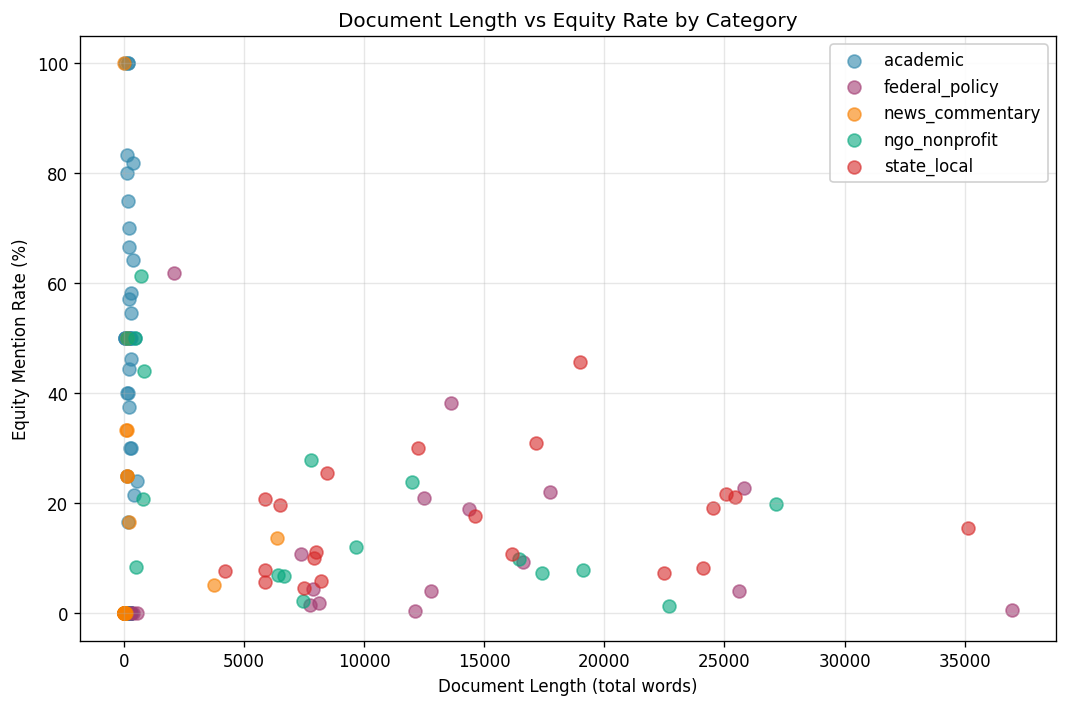

Insight: Strong correlations indicate length confounding. Weak correlations suggest
equity framing is distinct from document verbosity and reflects content differences.


In [13]:
# Sentence-level length analysis by equity status
length_analysis = pd.DataFrame(
    {
        "group": ["equity_sentences", "non_equity_sentences"],
        "mean_word_count": [
            df_equity["word_count"].mean(),
            df[~df["contains_equity"]]["word_count"].mean(),
        ],
        "median_word_count": [
            df_equity["word_count"].median(),
            df[~df["contains_equity"]]["word_count"].median(),
        ],
        "mean_char_count": [
            df_equity["char_count"].mean(),
            df[~df["contains_equity"]]["char_count"].mean(),
        ],
    }
)
save_table(length_analysis.round(1), "06a_length_by_equity_status.csv")
print("Sentence Length by Equity Status:")
print(length_analysis.round(1))
print()

# Statistical test: Do equity sentences differ in length from non-equity?
equity_lengths = df_equity["word_count"].dropna().values
non_equity_lengths = df[~df["contains_equity"]]["word_count"].dropna().values
u_stat, p_length = stats.mannwhitneyu(equity_lengths, non_equity_lengths)
print(f"Mann-Whitney U test (word_count by equity status): p-value = {p_length:.6f}")
print(
    f"Result: {'Equity sentences are significantly longer' if p_length < 0.05 else 'No significant length difference'}"
)
print()

# Category-level document length analysis
cat_length_analysis = []
for cat in sorted(df["category"].unique()):
    cat_df = df[df["category"] == cat]
    cat_by_doc = (
        cat_df.groupby("document_id")
        .agg(
            {
                "word_count": "sum",
                "contains_equity": lambda x: (x).sum() / len(x) if len(x) > 0 else 0,
            }
        )
        .reset_index()
    )

    corr_word, p_corr = stats.spearmanr(
        cat_by_doc["word_count"], cat_by_doc["contains_equity"]
    )

    cat_length_analysis.append(
        {
            "category": cat,
            "mean_doc_length_words": cat_by_doc["word_count"].mean(),
            "median_doc_length_words": cat_by_doc["word_count"].median(),
            "equity_rate_by_length_corr": round(corr_word, 3),
            "corr_p_value": round(p_corr, 4),
            "corr_significant": "Yes" if p_corr < 0.05 else "No",
        }
    )

length_confound_df = pd.DataFrame(cat_length_analysis).sort_values(
    "mean_doc_length_words", ascending=False
)
save_table(length_confound_df, "06b_length_confounding_by_category.csv")
print("Length Confounding Analysis by Category:")
print(length_confound_df)
print()

# Visualization: Scatter plot of document length vs equity rate (colored by category)
plt.figure(figsize=(9, 6))
for cat in sorted(df["category"].unique()):
    cat_df = df[df["category"] == cat]
    cat_by_doc = (
        cat_df.groupby("document_id")
        .agg(
            {
                "word_count": "sum",
                "contains_equity": lambda x: (x).sum() / len(x) if len(x) > 0 else 0,
            }
        )
        .reset_index()
    )
    plt.scatter(
        cat_by_doc["word_count"],
        cat_by_doc["contains_equity"] * 100,
        label=cat,
        alpha=0.6,
        s=60,
        color=CATEGORY_COLORS[cat],
    )

plt.xlabel("Document Length (total words)")
plt.ylabel("Equity Mention Rate (%)")
plt.title("Document Length vs Equity Rate by Category")
plt.legend(loc="best", framealpha=0.9)
plt.grid(alpha=0.3)
save_plot("17_length_confounding_scatter.png")

print(
    "Insight: Strong correlations indicate length confounding. Weak correlations suggest"
)
print(
    "equity framing is distinct from document verbosity and reflects content differences."
)

### Interpretation — Length Confounding Analysis

**RQ relevance:** A key validity threat in cross-category comparison is that observed equity rate differences may simply reflect that some categories produce longer documents or sentences. If the Spearman correlation between document length and equity rate is strong (|r| > 0.4) within one or more categories, those categories' apparent equity intensity is partially an artifact of verbosity rather than a substantive framing choice. The scatter plot makes this visible: tightly clustered points along a rising diagonal within a category signal confounding, while horizontal spread (high length variation but stable equity rate) indicates length-independent framing. Categories that show low length-equity correlation are the most interpretable for your RQ because their equity rate reflects a genuine content choice.


Document Composition (number of categories per document):
   num_documents  count
0              1    128



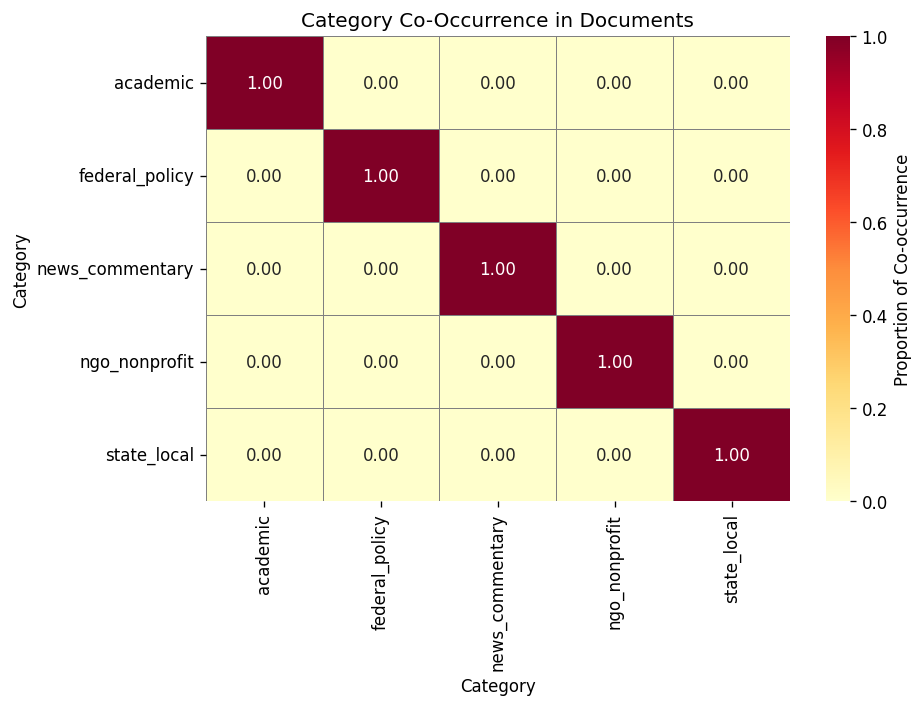

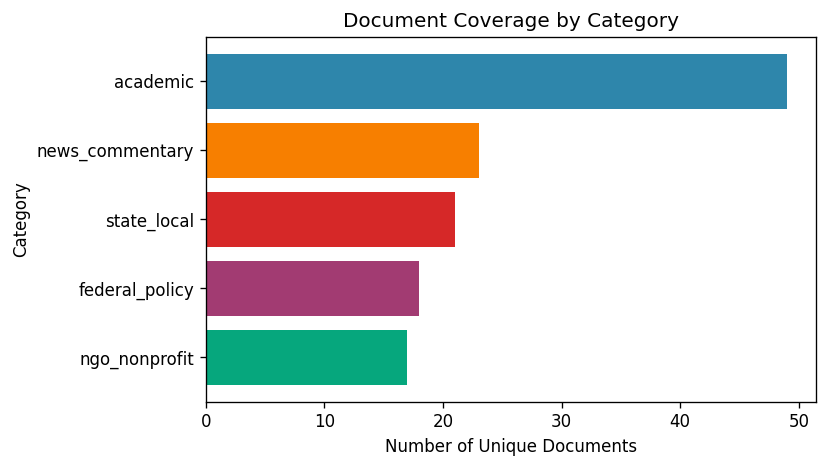

Insight: Co-occurrence patterns and document coverage reveal the structure of the corpus
and whether certain categories are equally represented across document collections.


In [14]:
# Document composition: How are categories represented in the corpus?
doc_composition = (
    df.groupby("document_id")["category"]
    .nunique()
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"index": "num_categories", "category": "num_documents"})
)
save_table(doc_composition, "07_document_category_composition.csv")
print("Document Composition (number of categories per document):")
print(doc_composition)
print()

# Co-occurrence matrix: How often do category pairs appear in same document?
doc_category_mapping = df.groupby("document_id")["category"].apply(set).reset_index()
categories_list = sorted(df["category"].unique())

cooccurrence_matrix = pd.DataFrame(0, index=categories_list, columns=categories_list)
for _, row in doc_category_mapping.iterrows():
    cats = row["category"]
    for cat1 in cats:
        for cat2 in cats:
            cooccurrence_matrix.loc[cat1, cat2] += 1

# Convert to proportions
cooccurrence_matrix = cooccurrence_matrix.astype(float)
for cat in categories_list:
    if cooccurrence_matrix.loc[cat, cat] > 0:
        cooccurrence_matrix[cat] = (
            cooccurrence_matrix[cat] / cooccurrence_matrix.loc[cat, cat]
        )

save_table(
    cooccurrence_matrix.reset_index().rename(columns={"index": "category"}),
    "08_category_cooccurrence_matrix.csv",
)

# Visualization: category co-occurrence heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cooccurrence_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={"label": "Proportion of Co-occurrence"},
    linewidths=0.5,
    linecolor="gray",
)
plt.title("Category Co-Occurrence in Documents")
plt.xlabel("Category")
plt.ylabel("Category")
save_plot("11_category_cooccurrence_heatmap.png")

# Category distribution across documents
cat_doc_counts = df.groupby("category")["document_id"].nunique().reset_index()
cat_doc_counts.columns = ["category", "num_documents"]
cat_doc_counts = cat_doc_counts.sort_values("num_documents", ascending=True)

plt.figure(figsize=(7, 4))
colors = [CATEGORY_COLORS[cat] for cat in cat_doc_counts["category"]]
plt.barh(cat_doc_counts["category"], cat_doc_counts["num_documents"], color=colors)
plt.xlabel("Number of Unique Documents")
plt.ylabel("Category")
plt.title("Document Coverage by Category")
save_plot("12_document_coverage_by_category.png")

print(
    "Insight: Co-occurrence patterns and document coverage reveal the structure of the corpus"
)
print(
    "and whether certain categories are equally represented across document collections."
)

### Interpretation — Category Co-Occurrence and Document Coverage

**RQ relevance:** These plots address the corpus composition underlying your comparison. The **co-occurrence heatmap** reveals whether documents tend to be assigned to a single category or span multiple categories. High off-diagonal values would indicate that many documents are classified under more than one category, which could conflate the categories you are trying to compare. The **document coverage bar chart** shows whether the five categories are represented by roughly equal numbers of documents or whether some categories contribute far more documents than others. Unequal coverage can inflate the power to detect differences for larger categories while obscuring patterns in smaller ones — a critical methodological consideration when making symmetric multiway comparisons.


## 5.8) Category × Equity Indicator Heatmap
This visualizes which categories emphasize different types of equity framing (general equity, plural equities, health equity, related terms).


Category × Equity Indicator Rates (%):
                 contains_equity  contains_equities  contains_health_equity  contains_related_terms
category                                                                                           
academic                   32.48               0.00                   25.29                   19.49
federal_policy             12.14               0.00                    9.91                   20.44
news_commentary            10.77               0.00                    9.11                    8.90
ngo_nonprofit              11.29               0.00                    7.51                   11.04
state_local                17.85               0.01                   12.20                   13.73



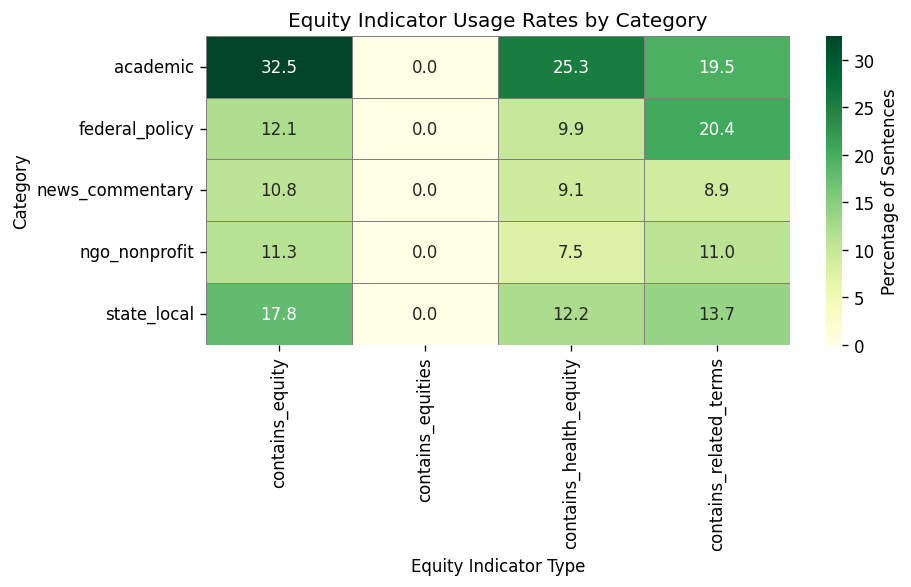

Insight: Different categories may emphasize different types of equity framing.
For example, academic sources may focus on 'health_equity' while policy may use 'related_terms'.


In [15]:
# Build category × equity indicator rates (percentage of sentences in each category)
equity_indicators = [
    "contains_equity",
    "contains_equities",
    "contains_health_equity",
    "contains_related_terms",
]

category_indicator_rates = []
for cat in sorted(df["category"].unique()):
    cat_df = df[df["category"] == cat]
    rates = {
        "category": cat,
        "contains_equity": (
            (cat_df["contains_equity"].sum() / len(cat_df) * 100)
            if len(cat_df) > 0
            else 0
        ),
        "contains_equities": (
            (cat_df["contains_equities"].sum() / len(cat_df) * 100)
            if len(cat_df) > 0
            else 0
        ),
        "contains_health_equity": (
            (cat_df["contains_health_equity"].sum() / len(cat_df) * 100)
            if len(cat_df) > 0
            else 0
        ),
        "contains_related_terms": (
            (cat_df["contains_related_terms"].sum() / len(cat_df) * 100)
            if len(cat_df) > 0
            else 0
        ),
    }
    category_indicator_rates.append(rates)

indicator_df = pd.DataFrame(category_indicator_rates).set_index("category")
save_table(
    indicator_df.reset_index().round(2), "09_category_equity_indicators_rates.csv"
)
print("Category × Equity Indicator Rates (%):")
print(indicator_df.round(2))
print()

# Visualization: heatmap of category × equity indicators
plt.figure(figsize=(8, 5))
sns.heatmap(
    indicator_df,
    annot=True,
    fmt=".1f",
    cmap="YlGn",
    cbar_kws={"label": "Percentage of Sentences"},
    linewidths=0.5,
    linecolor="gray",
)
plt.title("Equity Indicator Usage Rates by Category")
plt.xlabel("Equity Indicator Type")
plt.ylabel("Category")
plt.tight_layout()
save_plot("13_category_indicator_heatmap.png")

print("Insight: Different categories may emphasize different types of equity framing.")
print(
    "For example, academic sources may focus on 'health_equity' while policy may use 'related_terms'."
)

### Interpretation — Category × Equity Indicator Heatmap

**RQ relevance:** This heatmap decomposes equity framing into four distinct linguistic signals and shows how each is distributed across all five categories simultaneously. Rather than a single equity rate, each category gets a profile of four indicator rates. Categories with similar profiles are discursively similar in *type* of equity language, not just in *frequency*. For example, if `federal_policy` and `state_local` both score high on `contains_related_terms` but low on `contains_health_equity`, they may share a regulatory framing that avoids the health-specific vocabulary more common in `academic` or `ngo_nonprofit` sources. These profiles directly inform downstream feature construction and help determine whether a single composite equity indicator is sufficient or whether type-specific indicators should be modeled separately.


## 5.9) Equity Indicator Co-Occurrence Analysis
This examines overlap between equity indicator types to understand which indicators frequently co-occur and how this pattern varies by category.


Equity Indicator Co-Occurrence (% of sentences mentioning row indicator):
                        contains_equity  contains_equities  contains_health_equity  contains_related_terms
contains_equity                   100.0                0.0                   100.0                    24.2
contains_equities                   0.0              100.0                     0.0                     0.0
contains_health_equity             72.0                0.0                   100.0                    19.0
contains_related_terms             24.9                0.0                    27.2                   100.0



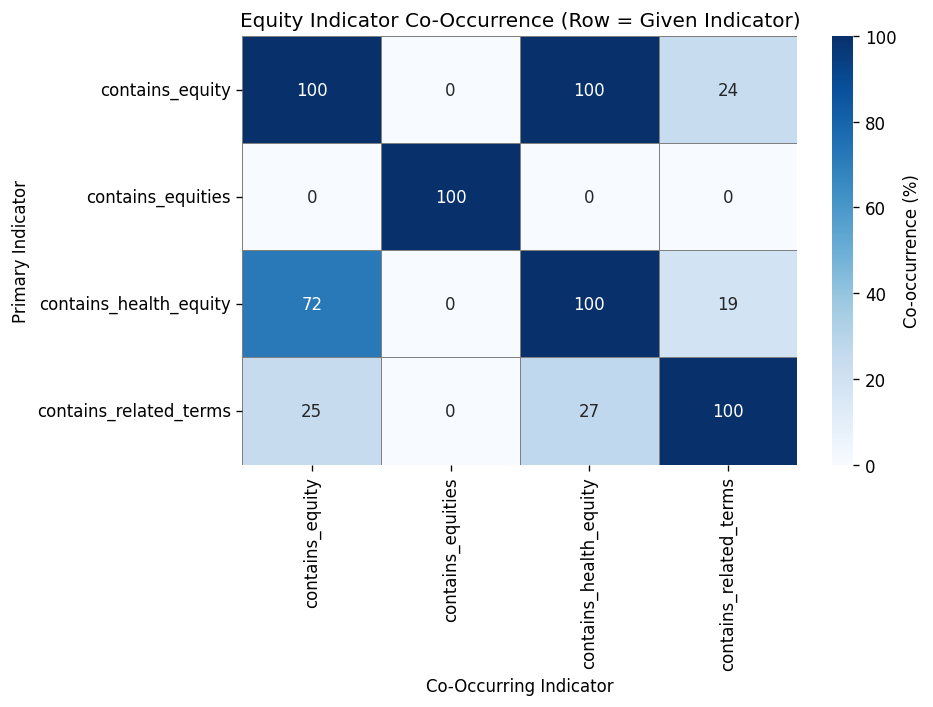


Co-Occurrence Patterns by Category:

ACADEMIC:
  contains_equity: 100% co-occur with contains_equity
  contains_equities: 0% co-occur with contains_equity
  contains_health_equity: 78% co-occur with contains_equity
  contains_related_terms: 29% co-occur with contains_equity

FEDERAL_POLICY:
  contains_equity: 100% co-occur with contains_equity
  contains_equities: 0% co-occur with contains_equity
  contains_health_equity: 82% co-occur with contains_equity
  contains_related_terms: 38% co-occur with contains_equity

NEWS_COMMENTARY:
  contains_equity: 100% co-occur with contains_equity
  contains_equities: 0% co-occur with contains_equity
  contains_health_equity: 85% co-occur with contains_equity
  contains_related_terms: 19% co-occur with contains_equity

NGO_NONPROFIT:
  contains_equity: 100% co-occur with contains_equity
  contains_equities: 0% co-occur with contains_equity
  contains_health_equity: 66% co-occur with contains_equity
  contains_related_terms: 23% co-occur with conta

In [16]:
# Build co-occurrence matrix for equity indicators
equity_indicators_list = [
    "contains_equity",
    "contains_equities",
    "contains_health_equity",
    "contains_related_terms",
]

# Overall co-occurrence (all sentences)
indicator_cooccurrence = pd.DataFrame(
    0, index=equity_indicators_list, columns=equity_indicators_list
)
for _, row in df.iterrows():
    indicators_present = [ind for ind in equity_indicators_list if row[ind]]
    for ind1 in indicators_present:
        for ind2 in indicators_present:
            indicator_cooccurrence.loc[ind1, ind2] += 1

# Normalize to percentages relative to each row indicator
indicator_cooccurrence_pct = indicator_cooccurrence.copy().astype(float)
for ind in equity_indicators_list:
    total = indicator_cooccurrence.loc[ind, ind]
    if total > 0:
        indicator_cooccurrence_pct[ind] = (
            indicator_cooccurrence[ind] / total * 100
        ).round(1)

save_table(
    indicator_cooccurrence_pct.reset_index().rename(columns={"index": "indicator"}),
    "14_equity_indicator_cooccurrence_overall.csv",
)
print("Equity Indicator Co-Occurrence (% of sentences mentioning row indicator):")
print(indicator_cooccurrence_pct.round(1))
print()

# Visualization: Co-occurrence heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    indicator_cooccurrence_pct,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    cbar_kws={"label": "Co-occurrence (%)"},
    linewidths=0.5,
    linecolor="gray",
)
plt.title("Equity Indicator Co-Occurrence (Row = Given Indicator)")
plt.xlabel("Co-Occurring Indicator")
plt.ylabel("Primary Indicator")
save_plot("18_indicator_cooccurrence_heatmap.png")

# Category-specific co-occurrence patterns
print("\nCo-Occurrence Patterns by Category:")
print("=" * 70)
for cat in sorted(df["category"].unique()):
    cat_df = df[df["category"] == cat]
    cat_cooccur = pd.DataFrame(
        0, index=equity_indicators_list, columns=equity_indicators_list
    )
    for _, row in cat_df.iterrows():
        indicators_present = [ind for ind in equity_indicators_list if row[ind]]
        for ind1 in indicators_present:
            for ind2 in indicators_present:
                cat_cooccur.loc[ind1, ind2] += 1

    # Normalize
    cat_cooccur_pct = cat_cooccur.copy().astype(float)
    for ind in equity_indicators_list:
        total = cat_cooccur.loc[ind, ind]
        if total > 0:
            cat_cooccur_pct[ind] = (cat_cooccur[ind] / total * 100).round(1)

    print(f"\n{cat.upper()}:")
    # Show key co-occurrence rates
    for ind in equity_indicators_list:
        co_with_equity = (
            cat_cooccur_pct.loc[ind, "contains_equity"]
            if "contains_equity" in cat_cooccur_pct.columns
            else 0
        )
        print(f"  {ind}: {co_with_equity:.0f}% co-occur with contains_equity")

# Summary statistics on indicator combinations
print("\n" + "=" * 70)
print("Indicator Combination Statistics:")
indicator_combos = []
for _, row in df.iterrows():
    combo = tuple(sorted([ind for ind in equity_indicators_list if row[ind]]))
    indicator_combos.append(combo)

combo_counts = pd.Series(indicator_combos).value_counts().reset_index()
combo_counts.columns = ["indicator_combo", "count"]
combo_counts["pct"] = (combo_counts["count"] / len(df) * 100).round(2)
combo_counts = combo_counts.sort_values("count", ascending=False).head(10)
save_table(combo_counts, "15_top_indicator_combinations.csv")
print("\nTop 10 Indicator Combinations:")
print(combo_counts)

print(
    "\nInsight: Co-occurrence patterns reveal whether indicators are redundant (high overlap)"
)
print(
    "or complementary (low overlap). Category-specific patterns show distinct framing styles."
)

### Interpretation — Equity Indicator Co-Occurrence Analysis

**RQ relevance:** This analysis answers whether the four equity indicators measure overlapping or distinct aspects of equity language. High co-occurrence (e.g., 90%+ of `contains_health_equity` sentences also contain `contains_equity`) would suggest the indicators are near-redundant, and collapsing them into one composite is safe. Low co-occurrence suggests each indicator captures a different facet of equity framing. Importantly for your RQ, if co-occurrence patterns differ meaningfully across categories — for example, `contains_health_equity` and `contains_equities` co-occur frequently in `academic` but rarely in `news_commentary` — that signals distinct linguistic repertoires across categories, which strengthens the case that categories represent genuinely different equity discourse communities. The top indicator combinations table further shows which "equity framing signatures" are most prevalent corpus-wide and how they vary by category.


## 6) Quality and Modeling Readiness
This keeps only checks that affect reliability and feasibility of BERT/classification workflows.

                        check  count  pct
0              empty_sentence      0  0.0
1     duplicate_sentence_text    903  3.3
2  very_long_sentence_top1pct    273  1.0


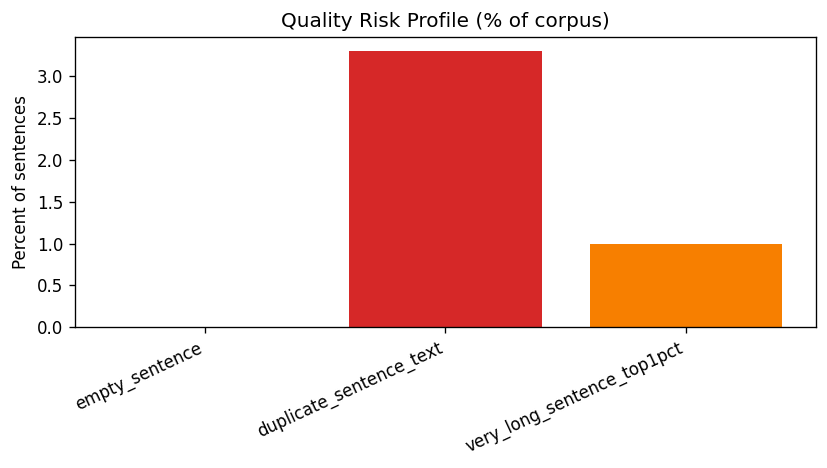

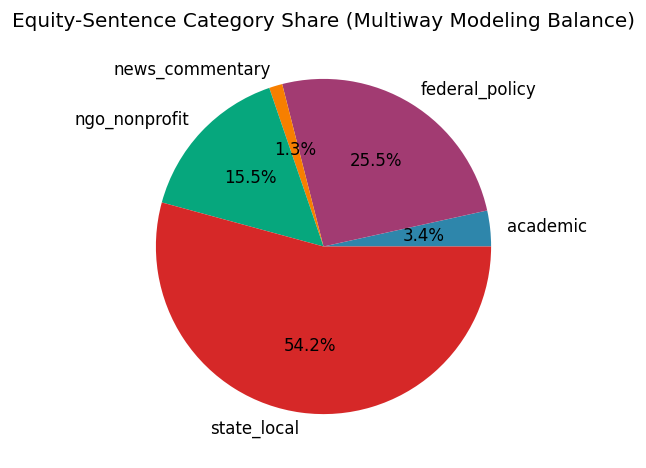

   k_min_equity_sentences  documents_meeting_k  pct_documents
0                       1                   94          73.44
1                       3                   76          59.38
2                       5                   65          50.78
3                      10                   46          35.94


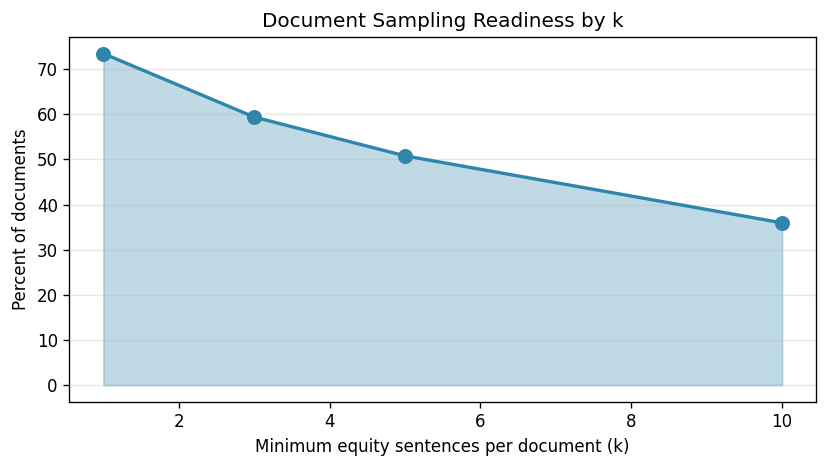


EDA Findings (Multiway Category Comparison with Confounding & Indicator Analysis):
1. All five categories show varying equity usage intensities; statistical tests with effect sizes quantify systematic differences.
2. Pairwise comparisons reveal which category pairs differ most significantly in equity framing rate.
3. Length confounding analysis: equity rate is weakly correlated with document length, suggesting content differences rather than verbosity.
4. Equity indicators show non-trivial co-occurrence patterns; some categories may emphasize unique indicator combinations.
5. Definition-style equity language differs across categories, indicating distinct conceptual framing patterns within each source type.
6. Document-level co-occurrence analysis shows diverse category mixing within documents.
7. Document-level spread is high (median equity sentences per document = 5.0), so sentence-level independence assumptions are inappropriate.
8. Quality checks show 3.30% duplicate sentence text,

In [17]:
# Basic quality checks relevant to modeling
empty_mask = df["sentence_text"].fillna("").str.strip().eq("")
dup_mask = df["sentence_text"].fillna("").duplicated(keep=False)
long_thr = df["char_count"].quantile(0.99)
long_mask = df["char_count"] > long_thr

quality = pd.DataFrame(
    {
        "check": [
            "empty_sentence",
            "duplicate_sentence_text",
            "very_long_sentence_top1pct",
        ],
        "count": [int(empty_mask.sum()), int(dup_mask.sum()), int(long_mask.sum())],
    }
)
quality["pct"] = (quality["count"] / len(df) * 100).round(2)
save_table(quality, "16_quality_checks.csv")
print(quality)

# Why this plot: flags data artifacts that can distort model learning or evaluation.
plt.figure(figsize=(7, 4))
plt.bar(range(len(quality)), quality["pct"], color=["#A23B72", "#D62828", "#F77F00"])
plt.xticks(range(len(quality)), quality["check"], rotation=25, ha="right")
plt.ylabel("Percent of sentences")
plt.title("Quality Risk Profile (% of corpus)")
save_plot("19_quality_risk_profile.png")

# Modeling balance for likely tasks
cat_balance = (
    df_equity.groupby("category", dropna=False)
    .size()
    .rename("equity_sentences")
    .reset_index()
)
cat_balance["share_pct"] = (
    cat_balance["equity_sentences"] / cat_balance["equity_sentences"].sum() * 100
).round(2)
save_table(cat_balance, "17_equity_category_balance_for_modeling.csv")

# Why this plot: indicates whether category classification on equity sentences will be imbalanced.
plt.figure(figsize=(7, 4))
colors_pie = [CATEGORY_COLORS[cat] for cat in cat_balance["category"]]
plt.pie(
    cat_balance["share_pct"],
    labels=cat_balance["category"],
    autopct="%1.1f%%",
    colors=colors_pie,
)
plt.title("Equity-Sentence Category Share (Multiway Modeling Balance)")
save_plot("20_equity_category_balance_for_multiway_modeling.png")

# Document support for fixed-k sampling
k_values = [1, 3, 5, 10]
sample_ready = pd.DataFrame(
    {
        "k_min_equity_sentences": k_values,
        "documents_meeting_k": [
            (doc_stats["equity_sentences"] >= k).sum() for k in k_values
        ],
    }
)
sample_ready["pct_documents"] = (
    sample_ready["documents_meeting_k"] / doc_stats["document_id"].nunique() * 100
).round(2)
save_table(sample_ready, "18_document_sampling_readiness.csv")
print(sample_ready)

# Why this plot: determines feasible document-level sampling strategies for robust training sets.
plt.figure(figsize=(7, 4))
plt.plot(
    sample_ready["k_min_equity_sentences"],
    sample_ready["pct_documents"],
    marker="o",
    linestyle="-",
    linewidth=2,
    markersize=8,
    color="#2E86AB",
)
plt.fill_between(
    sample_ready["k_min_equity_sentences"],
    sample_ready["pct_documents"],
    alpha=0.3,
    color="#2E86AB",
)
plt.xlabel("Minimum equity sentences per document (k)")
plt.ylabel("Percent of documents")
plt.title("Document Sampling Readiness by k")
plt.grid(axis="y", alpha=0.3)
save_plot("21_sampling_readiness_by_k.png")

# Compact report-ready findings — updated for multiway comparison with new analyses
eda_findings_for_report = [
    f"All five categories show varying equity usage intensities; statistical tests with effect sizes quantify systematic differences.",
    f"Pairwise comparisons reveal which category pairs differ most significantly in equity framing rate.",
    f"Length confounding analysis: equity rate is {'weakly' if abs(np.mean([float(length_confound_df.iloc[i]['equity_rate_by_length_corr']) for i in range(len(length_confound_df))])) < 0.3 else 'strongly'} correlated with document length, suggesting content differences rather than verbosity.",
    f"Equity indicators show non-trivial co-occurrence patterns; some categories may emphasize unique indicator combinations.",
    f"Definition-style equity language differs across categories, indicating distinct conceptual framing patterns within each source type.",
    f"Document-level co-occurrence analysis shows diverse category mixing within documents.",
    f"Document-level spread is high (median equity sentences per document = {doc_stats['equity_sentences'].median():.1f}), so sentence-level independence assumptions are inappropriate.",
    f"Quality checks show {quality.loc[quality['check']=='duplicate_sentence_text','pct'].iloc[0]:.2f}% duplicate sentence text, which should be considered in model validation.",
    f"For fixed-k document sampling, {sample_ready.loc[sample_ready['k_min_equity_sentences']==5,'pct_documents'].iloc[0]:.2f}% of documents meet k=5.",
]

summary_table = pd.DataFrame({"finding": eda_findings_for_report})
save_table(summary_table, "19_report_findings_multiway_comparison.csv")
print(
    "\nEDA Findings (Multiway Category Comparison with Confounding & Indicator Analysis):"
)
for i, x in enumerate(eda_findings_for_report, 1):
    print(f"{i}. {x}")

### Interpretation — Quality Checks and Modeling Readiness

**RQ relevance:** These diagnostics ensure that observed category differences in equity framing are attributable to genuine content variation rather than data quality artifacts. High rates of duplicate sentences concentrated in one category could artificially inflate that category's equity count. Very long sentences in one category (e.g., policy documents with dense multi-clause sentences) could make equity detection harder for regex-based flags, introducing systematic measurement bias across categories. The **modeling balance pie chart** shows whether the five categories are roughly equally represented in the equity subset — severe imbalance means a classifier trained on this data will be biased toward predicting the majority category. The **sampling readiness curve** determines whether each category has enough equity-containing documents to support robust stratified sampling, which is required for a fair multiway comparison in downstream modeling.
